In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
from vqniche.utils.parse_test_configs import *
from vqniche.initializers.initialize import *
from vqniche import metrics
from vqniche.utils.type_conversions import *
from vqniche.utils.adjacency_reconstruction import reconstruct_adjacency_matrix as construct_binary_adjacency_matrix

/software/cellgen/team361/am84/envs/vqniche-reproducibility/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/software/cellgen/team361/am84/envs/vqniche-reproducibility/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/software/cellgen/team361/am84/envs/vqniche-reproducibility/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain

In [3]:
# --------------------- Import Libraries ---------------------
import os
import sys
import yaml
import pickle
from pathlib import Path

import scanpy as sc
import anndata as ad
import squidpy as sq
import seaborn as sns
import pandas as pd
import numpy as np
import networkx as nx
import scipy.sparse as sp
import matplotlib.pyplot as plt

import torch
import pytorch_lightning as pl
import torch_geometric.transforms as T
from torch_geometric.data import Batch
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_dense_adj

## Functions

### Initialize

In [4]:
def build_inference_adata(
        inference_data: Dict,
        dataset_blob: InMemoryDataset,
    ) -> ad.AnnData:
    """
    Build an AnnData object from inference data dictionary and dataset blob.
    
    Parameters
    ----------
    inference_data : Dict
        Dictionary containing inference results with keys:
        - 'X': Input features (torch.Tensor)
        - 'Y_cell_type': Cell type labels as one-hot vectors (torch.Tensor)
        - 'Y_niche_type': Niche type labels as one-hot vectors (torch.Tensor)
        - 'edge_index': Edge indices (torch.Tensor)
        - 'H_latent': Latent representations (torch.Tensor)
        - 'X_hat': Reconstructed features (torch.Tensor)
        - 'H_adj': Adjacency representations (torch.Tensor)
        - 'H_quantized': Quantized representations (torch.Tensor, optional)
        - 'Indices': Quantization indices (torch.Tensor, optional)
    dataset_blob
        Dataset blob object containing label categories and gene panel information.
    
    Returns
    -------
    ad.AnnData
        AnnData object with inference results stored in appropriate slots.
    """
    # Create AnnData object with input features
    adata = ad.AnnData(X=inference_data['X'].cpu().numpy())
    
    # Convert one-hot labels to string labels
    for label_name, labels in inference_data['label_categories'].items():
        # if label_name == 'cell_types':
            # label_key = 'cell_type'
        # elif label_name == 'niche_types':
            # label_key = 'niche_type'
        names = torch_one_hot_to_label_name(
                                    one_hot=inference_data[f'Y_{label_name}'],
                                    label_categories=list(inference_data['label_categories'][label_name])
                                )
        names.index = adata.obs.index
        adata.obs[label_name] = names
        
    # adata.obs['niche_type'] = pd.Series(np.argmax(inference_data['Y_niche_type'].cpu(), axis=1)).astype('category')
    adata.obsm['spatial'] = inference_data['XY_coordinates'].cpu().numpy()

    # Store embeddings in obsm
    adata.obsm['H_latent'] = inference_data['H_latent'].cpu().numpy()
    adata.obsm['X_hat'] = inference_data['X_hat'].cpu().numpy()
    adata.obsm['H_adj'] = inference_data['H_adj'].cpu().numpy()
    
    # Convert edge index to adjacency matrix and store in obsp
    edge_index = inference_data['edge_index']
    adj_matrix = to_dense_adj(edge_index)[0]
    sparse_adj = sp.csr_matrix(adj_matrix.cpu().numpy())
    adata.obsp['spatial_connectivities'] = sparse_adj
    
    # Add H_quantized and Indices only if they exist
    if 'H_quantized' in inference_data:
        adata.obsm['H_quantized'] = inference_data['H_quantized'].cpu().numpy()
    
    if 'Indices' in inference_data:
        adata.obs['Indices'] = inference_data['Indices'].cpu().numpy()
    
    return adata

In [5]:
def load_everything(
        config: Dict,
        model_ckpt_fname: Optional[str] = None,
    ):
    """
    Load all the necessary components for a model run.
    
    Parameters
    ----------
    config: Dict
        A dictionary containing the configuration parameters for the model run.
    
    Returns
    -------
    - None
    """
    # --------------------- Determinism Settings ---------------------
    pl.seed_everything(config['experiment']['seed'])

    # --------------------- Dataset ---------------------
    dataset_blob = initialize_dataset_blob(config)
    with open(Path(dataset_blob.processed_dir) / 'label_categories.pkl', 'rb') as f:
        label_categories = pickle.load(f)

    # --------------------- Databatch ---------------------
    data_batch = initialize_databatch(
                    config=config,
                    dataset_blob=dataset_blob,
                )
    
    # --------------------- Dataloader ---------------------
    datamodule_batch = initialize_datamodule(
                            config=config,
                            data=data_batch,
                        )

    # --------------------- Model ---------------------
    Model = set_model_class(config['model']['model_name'])
    if model_ckpt_fname is None:
        model_ckpt_fname = find_best_checkpoint(config['experiment']['wandb_run_dir'])
    model = Model.load_from_checkpoint(model_ckpt_fname)
    
    # --------------------- Trainer ---------------------
    strategy = "ddp_notebook"
    # strategy = "ddp"
    
    trainer = pl.Trainer(
                    accelerator="auto",
                    devices="auto",
                    deterministic=True,
                    logger=False,
                    callbacks=False,
                    strategy=strategy,
                    max_epochs=config['trainer']['max_epochs'],
                    enable_checkpointing=False,
                    num_sanity_val_steps=0,
                    enable_progress_bar=False,
                    enable_model_summary=True,
                )
    
    inference_data = model.collect_inference_data(
                    datamodule_batch.infer_dataloader()
                )
    inference_data['label_categories'] = label_categories
    
    return dataset_blob, \
        data_batch, \
        datamodule_batch, \
        model, \
        trainer, \
        inference_data

In [6]:
def compute_umap(
        adata: ad.AnnData,
        embedding_keys: List[str] = ['X'],
    ) -> ad.AnnData:
    """
    This function computes the nearest neighbor distance matrix and neighborhood graph,
    and embeds the neighborhood into 2D using UMAP.
    
    Parameters
    ----------
    adata : ad.AnnData
        AnnData object with the data to be processed.
    embedding_keys : List[str]
        Key(s) in adata.obsm to compute UMAP embeddings of.
    
    Returns
    -------
    adata : ad.AnnData
        AnnData object with the UMAP embedding(s) added to adata.obsm.
    """
    for embedding_key in embedding_keys:
        print(f"Computing UMAP for {embedding_key}..")
        if embedding_key == 'X':
            print(f"{np.mean(adata.X)=}")
        else:
            print(f"{np.mean(adata.obsm[embedding_key])=}")
        # compute nearest neighbor distance matrix and neighborhood graph
        sc.pp.neighbors(
            adata=adata,
            n_neighbors=15, # default is 15
            knn=True, # default is True
            random_state=42,
            use_rep=embedding_key,
            key_added=f'{embedding_key}_neighbors',
        )
        #  The neighbors data is added to .uns[key_added], distances are stored in .obsp[key_added+'_distances'] and connectivities in .obsp[key_added+'_connectivities'].

        # embed the neighborhood into 2D using UMAP
        sc.tl.umap(
            adata=adata,
            min_dist=0.5, # default is 0.5
            spread=1.0, # default is 1.0
            alpha=1.0, # default is 1.0
            gamma=1.0, # default is 1.0
            negative_sample_rate=5, # default is 5
            random_state=42,
            neighbors_key=f'{embedding_key}_neighbors',
            key_added=f'{embedding_key}_umap',
        )
        # The embedding is stored as obsm[key_added] and the the parameters in uns[key_added].

    return adata

### Model Training

In [ ]:
def read_train_val_metrics(
        wandb_run_dir: Path = None,
    ) -> pd.DataFrame:
    """
    This function reads all metrics logged to output log file during each training epoch and returns them as a Pandas DataFrame.
    
    Parameters
    ----------
    wandb_run_dir : str | Path
        Path to the wandb run directory containing the output log file.
        
    Returns
    -------
    df: pd.DataFrame
        DataFrame containing all metrics logged during each training epoch.
        
    Notes:
    ------
    - This expects that the log file is named 'train_val_epoch_metrics.csv' and is located in the 'files' directory of the wandb run directory.
    - The log file is expected to have loss terms and accuracies as headings and their corresponding values as rows.
    - All other lines in the log file are ignored.
    - The metrics are various losses and accuracies logged during training and validation epochs.
    """
    logfile = wandb_run_dir / 'files' / 'train_val_epoch_metrics.csv'
    raw_df = pd.read_csv(logfile)

    # replace 'nan' strings with actual NaN values
    raw_df.replace('nan', np.nan, inplace=True)

    return raw_df

### Model Testing

### Plotting

In [ ]:
def plot_train_val_metrics(
        loss_df: pd.DataFrame,
        test_acc: float = None,
    ):
    """
    This function plots all metrics logged during training and validation epochs.
    
    Parameters
    ----------
    loss_df : pd.DataFrame
        DataFrame containing all metrics logged during each training epoch.
    test_acc : float
        Test accuracy of the model.
    
    Returns
    -------
    None
    """
    # Melt the dataframe to have a 'Mode' column for 'Train' and 'Val'
    df = loss_df.melt(id_vars=['epoch'], 
                        value_vars=['train_cross_entropy', 'val_cross_entropy', 
                                    'train_mse_attribute_reconstruction', 'val_mse_attribute_reconstruction', 
                                    'train_mse_adjacency_reconstruction', 'val_mse_adjacency_reconstruction', 
                                    'train_mse_commitment_loss', 'val_mse_commitment_loss', 
                                    'train_l2_codebook_loss', 'val_l2_codebook_loss', 
                                    'train_loss', 'val_loss'],
                        var_name='Loss Term', value_name='Value')

    # Create 'Mode' column
    df['Mode'] = df['Loss Term'].apply(lambda x: 'Train' if 'train' in x else 'Val')

    # Simplify 'Loss Term' column
    df['Loss Term'] = df['Loss Term'].apply(lambda x: x.replace('train_', '').replace('val_', ''))

    # Replace metric values with proper names
    metric_names = {
        'cross_entropy': 'Cross Entropy Loss',
        'mse_attribute_reconstruction': 'MSE Attr. Reconstr.',
        'mse_adjacency_reconstruction': 'MSE Adj. Reconstr.',
        'mse_commitment_loss': 'MSE Commit Loss',
        'l2_codebook_loss': 'L2 Codebook Loss',
        'loss': 'Total Loss'
    }

    df['Loss Term'] = df['Loss Term'].map(metric_names)

    # Create a column to indicate if the metric value is NaN
    df['isNaN'] = df['Value'].isna()

    # Group by 'Loss Term' and replace NaN with 1.1 * max value for each group
    df['Value'] = df.groupby('Loss Term')['Value'].transform(lambda x: x.fillna(1.1 * x.max()))
    display(df)
        
    loss_terms = df['Loss Term'].unique()

    fig, axes = plt.subplots(2, 3, figsize=(12,8))

    for ax, loss_term in zip(axes.flatten(), loss_terms):
        sns.lineplot(data=df[df['Loss Term'] == loss_term], x='epoch', y='Value', hue='Mode', style='isNaN', markers=True, dashes=False, ax=ax)

        handles, labels = ax.get_legend_handles_labels()
        ax.get_legend().remove()

        ax.set_xlabel('Epoch')
        ax.set_ylabel(loss_term)
        ax.set_title(loss_term)
    
    fig.legend(
        handles,
        labels,
        bbox_to_anchor=(0.5,-0.08),
        loc='lower center',
        ncol=2,
    )

    fig.suptitle(f"Test Accuracy: {test_acc:.2f}", fontsize=16)

    plt.tight_layout()
    plt.show()

In [7]:
def plot_umap(  
        adata: ad.AnnData,
        embedding_keys: list[str],
        label_key: str = 'cell_types',
    ):
    """
    This function plots the UMAP embedding of the data.
    
    Parameters
    ----------
    adata : ad.AnnData
        AnnData object with the data to be processed.
    embedding_keys : list[str]
        Keys in adata.obsm to use for the embedding.
    label_key : str
        Key in adata.obs to use for the label.
    
    Returns
    -------
    None
    """
    # Create subplots with extra space for legend
    fig, axes = plt.subplots(1, len(embedding_keys), figsize=(12, 4))
    if len(embedding_keys) == 1:
        axes = [axes]
    
    flag = 1
    
    for ax, embedding_key in zip(axes, embedding_keys):
        if flag:
            legend_loc = None
        else:
            legend_loc = 'right margin'
        sc.pl.umap(
            adata=adata,
            color=label_key,
            layer=f'{embedding_key}_umap',
            neighbors_key=f'{embedding_key}_neighbors',
            show=False,
            ax=ax,
            legend_loc=legend_loc,  # Don't show individual legends
        )
        flag = 0
        
        ax.set_title(embedding_key)

        # Add title to the legend on the first plot
        if flag == 0:  # This is the first plot (flag was 1, now set to 0)
            legend = ax.get_legend()
            if legend:
                legend.set_title(label_key)        
        
    plt.show()

In [8]:
def plot_graph_spatial_layout(
        G: nx.Graph,
        G_hat: nx.Graph,
        label_list: list,
        label_key: str = 'cell_types',
        figsize: tuple = (12, 4),
        layout_algorithm: str = 'spring'
    ):
    """
    This function plots the layout of original and imputed graphs colored by the label.
    
    Parameters
    ----------
    G : nx.Graph
        Original networkx graph with node attributes.
    G_hat : nx.Graph
        Imputed networkx graph with node attributes.
    label_list : list
        List of labels corresponding to nodes (same order as G.nodes()).
    label_key : str
        Key in node attributes to use for coloring nodes.
    figsize : tuple
        Figure size (width, height).
    layout_algorithm : str
        Layout algorithm to use for positioning nodes.
        Options: 'spring', 'circular', 'random', 'shell', 'kamada_kawai'
    
    Returns
    -------
    None
    """
    # Add labels as node attributes to both graphs
    for i, node in enumerate(G.nodes()):
        if i < len(label_list):
            G.nodes[node][label_key] = label_list[i]
            G_hat.nodes[node][label_key] = label_list[i]
        else:
            # Handle case where there are more nodes than labels
            G.nodes[node][label_key] = 'Unknown'
            G_hat.nodes[node][label_key] = 'Unknown'
    
    # Create subplots
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Get node labels for both graphs
    labels_G = nx.get_node_attributes(G, label_key)
    labels_G_hat = nx.get_node_attributes(G_hat, label_key)
    
    # Generate positions using layout algorithm
    if layout_algorithm == 'spring':
        pos_G = nx.spring_layout(G)
        pos_G_hat = nx.spring_layout(G_hat)
    elif layout_algorithm == 'circular':
        pos_G = nx.circular_layout(G)
        pos_G_hat = nx.circular_layout(G_hat)
    elif layout_algorithm == 'random':
        pos_G = nx.random_layout(G)
        pos_G_hat = nx.random_layout(G_hat)
    elif layout_algorithm == 'shell':
        pos_G = nx.shell_layout(G)
        pos_G_hat = nx.shell_layout(G_hat)
    elif layout_algorithm == 'kamada_kawai':
        pos_G = nx.kamada_kawai_layout(G)
        pos_G_hat = nx.kamada_kawai_layout(G_hat)
    else:
        pos_G = nx.spring_layout(G)
        pos_G_hat = nx.spring_layout(G_hat)
    
    # Get unique labels for consistent coloring
    all_labels = set(labels_G.values()) | set(labels_G_hat.values())
    unique_labels = sorted(list(all_labels))
    
    # Create color map
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
    label_to_color = dict(zip(unique_labels, colors))
    
    # Plot original graph
    node_colors_G = [label_to_color.get(labels_G.get(node, 'Unknown'), 'gray') for node in G.nodes()]
    nx.draw(
        G, pos_G,
        node_color=node_colors_G,
        node_size=50,
        with_labels=False,
        ax=axes[0]
    )
    axes[0].set_title('Original Graph')
    
    # Plot imputed graph
    node_colors_G_hat = [label_to_color.get(labels_G_hat.get(node, 'Unknown'), 'gray') for node in G_hat.nodes()]
    nx.draw(
        G_hat, pos_G_hat,
        node_color=node_colors_G_hat,
        node_size=50,
        with_labels=False,
        ax=axes[1]
    )
    axes[1].set_title('Imputed Graph')
    
    # Create legend
    legend_elements = [plt.Line2D([0], [0], marker='o', color='w', 
                                  markerfacecolor=label_to_color[label], 
                                  markersize=10, label=label) 
                      for label in unique_labels]
    axes[1].legend(handles=legend_elements, title=label_key, loc='upper left', bbox_to_anchor=(1, 1))
    
    plt.tight_layout()
    plt.show()

## Analysis

### xhs1000-39b_1p (batch 11)

In [9]:
# set dataset name and batch id
dataset_name = 'xhs1000-39b_1p'
batch_id = 11

# set wandb run id
wandb_run_dir = Path('/nfs/team361/am84/VQNiche/logs/xhs1000-39b_1p/standalone/VQNiche/batch=[11]/spatial_n_neighs_8/wandb/run-20250708_114542-jwkl07ci')
# wandb_run_dir = Path('/nfs/team361/am84/VQNiche/logs/xhs1000-39b_1p/standalone/VQNiche/batch=[11]/spatial_n_neighs_8/wandb/run-20250710_132152-mf5mc7aq')
config = collect_test_configs(
    wandb_run_dir=wandb_run_dir,
)

Best checkpoint found: epoch=9-pearson_1hop_nbr=0.78.ckpt


In [10]:
# load everything
dataset_blob, \
data_batch, \
datamodule_batch, \
model, \
trainer, \
inference_data = load_everything(config)

Seed set to 0


SubsetHVG: Subsetted data to 1000 features.
Batch ID(s): [11]
Data Batch: DataBatch(y_cell_types=[17832, 41], y_niche_types=[17832, 15], xy_coordinates=[17832, 2], cell_id=[1], dataset_id=[1], tissue=[1], species=[1], adata_batch_id=[1], x=[17832, 1000], y=[17832, 41], edge_index=[2, 183562], num_features=1000, num_classes=41, num_nodes=17832, num_edges=[1], train_mask=[17832], val_mask=[17832], test_mask=[17832], batch=[17832], ptr=[2])
Number of Tissue Sections: 1
Loader Name: NeighborLoader
Num Workers: 2
Loader Name: NeighborLoader
Loader Class: <class 'torch_geometric.loader.neighbor_loader.NeighborLoader'>
Loader Params: {'batch_size': 512}
Sampler Name: NeighborSampler
Sampler Class: <class 'torch_geometric.sampler.neighbor_sampler.NeighborSampler'>
Sampler Params: {'num_neighbors': [5, 10]}
Sample Neighbors for Inference: False
Best checkpoint found: epoch=9-pearson_1hop_nbr=0.78.ckpt


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Setting the following loss terms as criterion for training:
Loss function: nb_attribute_reconstruction
Loss function: mse_adjacency_reconstruction
Loss function: mse_commit_loss
Loss function: mse_code_loss
Initializing linear layers with kaiming_uniform initialization method.
1. VQNiche Encoder: VQNiche_Encoder that transforms 1000 input features to 50 quantized features.
2. Attribute Decoder: MLPSoftmax that decodes 50 latent features to 1000 input features.
3. Adjacency Decoder: MLP_AdjacencyDecoder that decodes 50 latent features to 50 adjacency features.
4. Predictor: Linear that transforms 50 hidden features to 41 dimensional logits.


In [11]:
adata = build_inference_adata(
        inference_data=inference_data,
        dataset_blob=dataset_blob,
    )

In [12]:
adata

AnnData object with n_obs × n_vars = 17832 × 1000
    obs: 'cell_types', 'niche_types', 'Indices'
    obsm: 'spatial', 'H_latent', 'X_hat', 'H_adj', 'H_quantized'
    obsp: 'spatial_connectivities'

In [14]:
compute_umap(
    adata=adata,
    embedding_keys=['X', 'X_hat'],
)

Computing UMAP for X..
np.mean(adata.X)=0.093282804
Computing UMAP for X_hat..
np.mean(adata.obsm[embedding_key])=0.0932829


AnnData object with n_obs × n_vars = 17832 × 1000
    obs: 'cell_types', 'niche_types', 'Indices'
    uns: 'X_neighbors', 'X_umap', 'X_hat_neighbors', 'X_hat_umap'
    obsm: 'spatial', 'H_latent', 'X_hat', 'H_adj', 'H_quantized', 'X_umap', 'X_hat_umap'
    obsp: 'spatial_connectivities', 'X_neighbors_distances', 'X_neighbors_connectivities', 'X_hat_neighbors_distances', 'X_hat_neighbors_connectivities'

In [16]:
metrics_list = ['gcs', 'mlami', 'nasw']
metrics_values = metrics.compute_benchmarking_metrics(
                    adata=adata,
                    metrics=metrics_list,
                    cell_type_key='cell_type',
                    spatial_key='spatial',
                    latent_key='H_adj',
                    seed=42
                )
metrics_values

Using precomputed spatial nearest neighbor graph with 15 neighbors...
Using precomputed latent nearest neighbor graph with 15 neighbors...
Neighbor graphs computed. Elapsed time: 0 minutes 0 seconds.

Computing benchmarking metrics...
Computing MLAMI Metric...
Using precomputed spatial nearest neighbor graph...
Using precomputed latent nearest neighbor graph...
Computing spatial Leiden clusterings for entire dataset...
Computing latent Leiden clusterings...
Computing MLAMI for entire dataset...
MLAMI metric computed. Elapsed time: 0 minutes 26 seconds.

Computing GCS metric...
Using precomputed spatial nearest neighbor graph...
Using precomputed latent nearest neighbor graph...
Computing GCS for entire dataset...
GCS metric computed. Elapsed time: 0 minutes 26 seconds.

Computing NASW Metric...
Using precomputed latent nearest neighbor graph...
Computing latent Leiden clusterings...
Using precomputed latent Leiden clusters for resolution 0.1.
Using precomputed latent Leiden clusters fo

{'mlami': 0.19760299360996433,
 'gcs': 0.6758959494656902,
 'nasw': 0.4515385050326586}

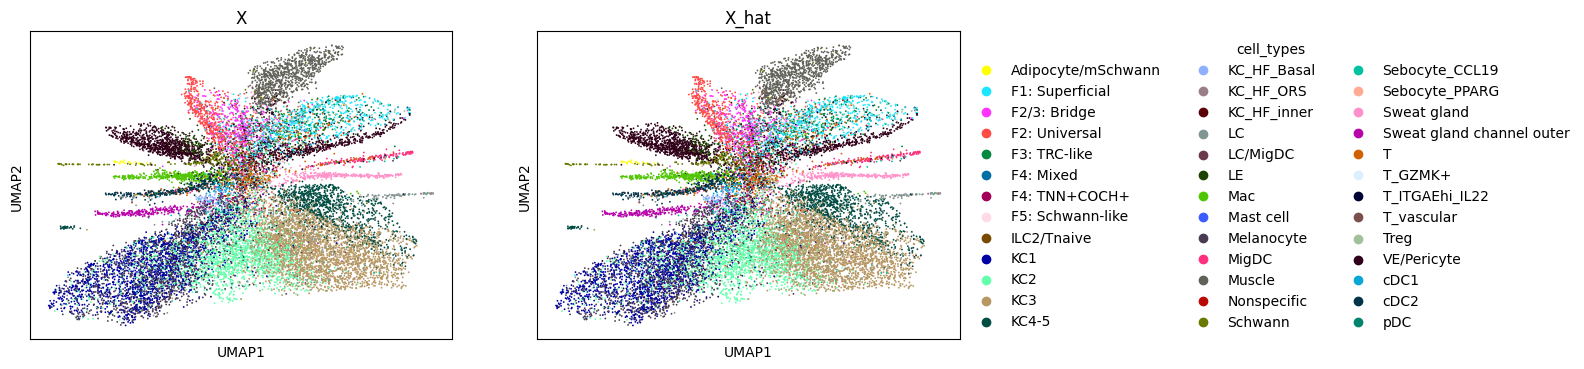

In [18]:
plot_umap(
    adata=adata,
    embedding_keys=['X', 'X_hat'],
    label_key='cell_types',
)

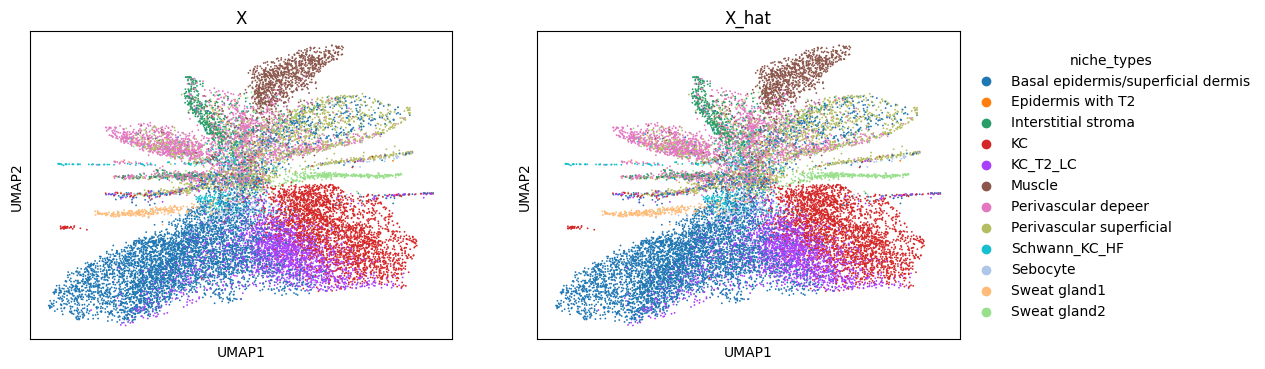

In [19]:
plot_umap(
    adata=adata,
    embedding_keys=['X', 'X_hat'],
    label_key='niche_types',
)

In [20]:
metrics_values = {'mlami': 0.1976, 'gcs': 0.6758, 'nasw': 0.4515}
metrics_values['MMD Degree'] = 0.4333
metrics_values['MMD Eigenvalues'] = 0.3333
metrics_values['Pearson 1hop Nbr'] = 0.8083

In [21]:
df = pd.DataFrame([
        {'metric': metric, 'score': score} 
        for metric, score in metrics_values.items()
    ])
df

,metric,score
0,mlami,0.1976
1,gcs,0.6758
2,nasw,0.4515
3,MMD Degree,0.4333
4,MMD Eigenvalues,0.3333
5,Pearson 1hop Nbr,0.8083


In [ ]:
metrics_values = {'mlami': 0.1976, 'gcs': 0.6758, 'nasw': 0.4515}
metrics_values['MMD Degree'] = 0.4333
metrics_values['MMD Eigenvalues'] = 0.3333
metrics_values['Pearson 1hop Nbr'] = 0.8083

In [13]:
G = nx.from_numpy_array(
                edge_index_to_adjacency_tensor(
                    inference_data['edge_index']
                ).cpu().numpy()
            )

In [14]:
G_hat = nx.from_numpy_array(
                construct_binary_adjacency_matrix(
                    h_index_nodes=inference_data['H_adj'].detach(),
                    nonlinearity='relu_clamp',
                    k=8
                ).cpu().numpy()
            )

KeyboardInterrupt: 

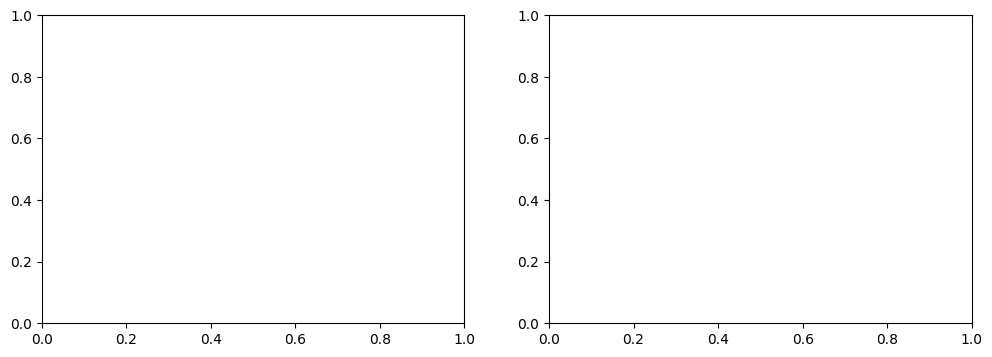

In [22]:
plot_graph_spatial_layout(
        G=G,
        G_hat=G_hat,
        label_list=list(adata.obs['cell_types']),
        label_key='cell_types',
        layout_algorithm='spatial',
    )

In [33]:
# set dataset name and batch id
dataset_name = 'xhs1000-39b_1p'
batch_id = 11

# set wandb run id
wandb_run_dir = Path('/nfs/team361/am84/VQNiche/logs/xhs1000-39b_1p/standalone/VQNiche/batch=[11]/spatial_n_neighs_8/wandb/run-20250710_132152-mf5mc7aq')
wandb_run_dir = Path('/nfs/team361/am84/VQNiche/logs/xhs1000-39b_1p/standalone/VQNiche/batch=[11]/spatial_n_neighs_8/wandb/run-20250710_133725-lrv5bpc3/logs')
config = collect_test_configs(
    wandb_run_dir=wandb_run_dir,
)

FileNotFoundError: [Errno 2] No such file or directory: '/nfs/team361/am84/VQNiche/logs/xhs1000-39b_1p/standalone/VQNiche/batch=[11]/spatial_n_neighs_8/wandb/run-20250710_133725-lrv5bpc3/logs/files/user_specified_config.yaml'

In [ ]:
# load everything
dataset_blob, \
data_batch, \
datamodule_batch, \
model, \
trainer, \
inference_data = load_everything(config)

In [ ]:
adata = build_inference_adata(
        inference_data=inference_data,
        dataset_blob=dataset_blob,
    )

In [ ]:
metrics_list = ['gcs', 'mlami', 'nasw']
metrics_values = metrics.compute_benchmarking_metrics(
                    adata=adata,
                    metrics=metrics_list,
                    cell_type_key='cell_type',
                    spatial_key='spatial',
                    latent_key='H_adj',
                    seed=42
                )
metrics_values

In [ ]:
metrics_values

In [28]:
metrics_values = {'mlami': 0.23232016509804188,
 'gcs': 0.6816553516922547,
 'nasw': 0.41658544912934303}
metrics_values['MMD Degree'] = 0.6822
metrics_values['MMD Eigenvalues'] = 0.6564
metrics_values['Pearson 1hop Nbr'] = 0.6726

In [30]:
df = pd.DataFrame([
        {'metric': metric, 'score': score} 
        for metric, score in metrics_values.items()
    ])
df

,metric,score
0,mlami,0.232320
1,gcs,0.681655
2,nasw,0.416585
3,MMD Degree,0.682200
4,MMD Eigenvalues,0.656400
5,Pearson 1hop Nbr,0.672600


In [31]:
G = nx.from_numpy_array(
                edge_index_to_adjacency_tensor(
                    inference_data['edge_index']
                ).cpu().numpy()
            )

In [32]:
pos = nx.spring_layout(G)

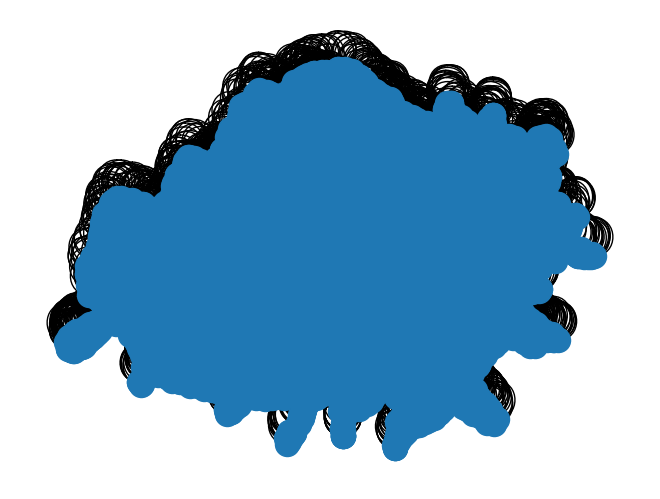

In [34]:
nx.draw(G, pos=nx.spring_layout(G))